# PaCMAP Figure With Fixed Parameters

Figure-oriented version of `pacmap_visualization.ipynb`. This notebook uses one predefined PaCMAP parameter set, caches the resulting coordinates, and exports one publication-style figure or an optional multi-measure panel. It can sweep color measures, but it does not sweep PaCMAP parameters.

**Fixed configuration copied from the old notebook:** the old notebook's fixed-measure section used:

```
SET_PACMAP_PARAMS = {"n_neighbors": 40, "MN_ratio": 0.25, "FP_ratio": 12.0}
SET_PACMAP_PLOT_SIZES = ["small"]
```

The same PaCMAP setting is used below as `PACMAP_PARAMS`; only the measure-selection, export, and optional panel assembly are changed.

In [29]:
import json
import re
from pathlib import Path

import colorcet as cc
import datashader as ds
import datashader.transfer_functions as tf
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pacmap
import pandas as pd
import pyarrow.parquet as pq
from PIL import Image, ImageDraw, ImageFont, ImageOps

## Configuration

In [ ]:
EMBED_DIR = Path("../../outputs/visualize/best_span_100k")
SOURCE_PARQUET = Path("../../data/pretrain/chembl36_selfies/train.parquet")
FIGURE_DIR = Path("../../figures/pacmap/manuscript_figures")

# Single predefined PaCMAP setting. Change this dict deliberately, then set
# FORCE_RECOMPUTE_COORDS=True if cached coordinates already exist.
PACMAP_PARAMS = {"n_neighbors": 40, "MN_ratio": 0.25, "FP_ratio": 12.0}
FORCE_RECOMPUTE_COORDS = False

# One measure by default. Set MEASURES_TO_PLOT = "all_available" to sweep
# all available numeric measures while keeping PACMAP_PARAMS fixed.
FIGURE_MEASURES = [
    "qed_weighted",
    "psa",
    "rotable_bonds",
    "num_ro5_violations",
    "heavy_atoms",
    "alogp",
]
MEASURES_TO_PLOT = "all_available"  # FIGURE_MEASURES
EXPORT_FORMATS = ["png", "pdf"]
MAKE_MEASURE_PANEL = True
PANEL_N_COLUMNS = 3
PANEL_TILE_WIDTH = 520
PANEL_PADDING = 18
ADD_TITLES = False  # Also colorbars

# Color-scale handling for measure plots.
# WINSORIZE_PERCENTILE=99 clips values to the central 98% interval: [1%, 99%].
# Mixed-sign measures use a zero-centered symmetric scale by default, so colorbars
# do not silently start at 0 or hide negative values.
WINSORIZE_PERCENTILE = 99.0
SIGNED_COLOR_SCALE = "symmetric"  # "symmetric" or "quantile"
# COLORBAR_TICK_COUNT gives each colorbar the same number of breaks.
# COLOR_LIMIT_OVERRIDES can pin limits per measure, e.g.
# {"alogp": (-8, 8), "qed_weighted": (0, 1)}.
# Colorbar ticks are chosen per measure. Integer-valued measures get integer ticks only.
# All colorbars include 0 unless a per-measure override explicitly says otherwise.
COLORBAR_MAX_TICKS = 6
COLOR_LIMIT_OVERRIDES = {}
INTEGER_MEASURES = {
    "hba",
    "hbd",
    "rtb",
    "rotable_bonds",
    "aromatic_rings",
    "heavy_atoms",
    "num_ro5_violations",
}
FORCE_COLORBAR_ZERO = True

# Source columns joined from SOURCE_PARQUET when not already usable in metadata.
EXTRA_COLUMNS = [
    "psa",
    "hba",
    "hbd",
    "qed_weighted",
    "mw_freebase",
    "rtb",
    "aromatic_rings",
    "heavy_atoms",
    "num_ro5_violations",
]

COLUMN_LABELS = {
    "alogp": "ALogP (lipophilicity)",
    "psa": "Polar surface area (A^2)",
    "hba": "H-bond acceptors",
    "hbd": "H-bond donors",
    "qed_weighted": "QED (drug-likeness)",
    "mw_freebase": "Molecular weight (Da)",
    "rtb": "Rotatable bonds",
    "aromatic_rings": "Aromatic rings",
    "heavy_atoms": "Heavy atom count",
    "num_ro5_violations": "Ro5 violations",
    "is_valid": "Valid SELFIES",
}

# Measures used by MEASURES_TO_PLOT="all_available". Keep boolean/categorical
# annotations like is_valid out of the numeric measure sweep.
NUMERIC_MEASURE_COLUMNS = [
    "alogp",
    "psa",
    "hba",
    "hbd",
    "qed_weighted",
    "mw_freebase",
    "rtb",
    "aromatic_rings",
    "heavy_atoms",
    "num_ro5_violations",
]

SEQUENTIAL_MEASURES = {
    "mw_freebase",
    "heavy_atoms",
    "aromatic_rings",
    "rtb",
    "num_ro5_violations",
    "psa",
    "hba",
    "hbd",
    "qed_weighted",
    "alogp",
}

FIGURE_SPEC = {
    "figsize": (6, 6),
    "dpi": 300,
    "datashader_spread_px": 2,
    "datashader_spread_shape": "circle",
    "title_size": 13,
    "colorbar_label_size": 8,
    "tick_label_size": 7,
    "colorbar_width": "2.5%",
    "colorbar_height": "28%",
    "colorbar_borderpad": 0.9,
}

COLORCET_SEQUENTIAL_CMAP = "CET_L17"
COLORCET_DIVERGENT_CMAP = "CET_D1A"

## Load Embeddings And Metadata

In [31]:
embeddings = np.load(EMBED_DIR / "embeddings.npy")
meta = pd.read_parquet(EMBED_DIR / "metadata.parquet")

print(f"Embeddings: {embeddings.shape}")
print(f"Metadata rows: {len(meta):,}")
print(f"Metadata columns: {meta.columns.tolist()}")

Embeddings: (100000, 512)
Metadata rows: 100,000
Metadata columns: ['chembl_id', 'smiles_canonical_clean', 'selfies', 'alogp', 'canonical_smiles', 'standard_inchi_key', 'is_valid', 'embedding_row']


In [32]:
if EXTRA_COLUMNS and SOURCE_PARQUET.exists():
    source_columns = set(pq.ParquetFile(SOURCE_PARQUET).schema.names)
    cols_to_load = []

    for col in EXTRA_COLUMNS:
        if col not in source_columns:
            continue
        if col not in meta.columns:
            cols_to_load.append(col)
            continue
        numeric = pd.to_numeric(meta[col], errors="coerce")
        if numeric.notna().sum() == 0:
            cols_to_load.append(col)

    if cols_to_load:
        meta = meta.drop(columns=[col for col in cols_to_load if col in meta.columns])
        props = pd.read_parquet(SOURCE_PARQUET, columns=["chembl_id", *cols_to_load])
        meta["chembl_id"] = meta["chembl_id"].astype(str).str.strip()
        props["chembl_id"] = props["chembl_id"].astype(str).str.strip()
        meta = meta.merge(props, on="chembl_id", how="left", validate="many_to_one")
        print(f"Joined/reloaded {cols_to_load} from source parquet")
    else:
        print("No source columns needed reloading")
elif EXTRA_COLUMNS:
    print(f"Source parquet not found; using metadata only: {SOURCE_PARQUET}")


def resolve_measures(selection):
    available = [
        col for col in NUMERIC_MEASURE_COLUMNS if col in meta.columns and meta[col].notna().any()
    ]
    if selection == "all_available":
        selected = available
    else:
        selected = list(selection)

    missing = [col for col in selected if col not in meta.columns]
    empty = [col for col in selected if col in meta.columns and not meta[col].notna().any()]
    if missing:
        raise ValueError(f"Selected measures missing from metadata: {missing}")
    if empty:
        raise ValueError(f"Selected measures have no non-null values: {empty}")

    # This figure notebook uses numeric colorbars. Categorical panels can be added
    # later, but the paper properties of interest are numeric.
    usable = []
    skipped = []
    for col in selected:
        values = pd.to_numeric(meta[col], errors="coerce").astype("float64")
        if values.notna().any():
            usable.append(col)
        else:
            skipped.append(col)

    if skipped:
        print(f"Skipped non-numeric/empty measures: {skipped}")
    if not usable:
        raise ValueError("No usable numeric measures selected")
    return usable


MEASURES = resolve_measures(MEASURES_TO_PLOT)
print(f"Measures to plot ({len(MEASURES)}): {MEASURES}")

Joined/reloaded ['psa', 'hba', 'hbd', 'qed_weighted', 'mw_freebase', 'rtb', 'aromatic_rings', 'heavy_atoms', 'num_ro5_violations'] from source parquet
Measures to plot (10): ['alogp', 'psa', 'hba', 'hbd', 'qed_weighted', 'mw_freebase', 'rtb', 'aromatic_rings', 'heavy_atoms', 'num_ro5_violations']


## Run One PaCMAP

In [33]:
def slug(value: object) -> str:
    text = str(value).replace(".", "p")
    return re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()


def pacmap_run_id(params: dict[str, float | int]) -> str:
    return (
        f"nn{params['n_neighbors']:03d}_mn{slug(params['MN_ratio'])}_fp{slug(params['FP_ratio'])}"
    )


RUN_ID = pacmap_run_id(PACMAP_PARAMS)
COORDS_PATH = FIGURE_DIR / f"{RUN_ID}_coords.npy"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if COORDS_PATH.exists() and not FORCE_RECOMPUTE_COORDS:
    coords = np.load(COORDS_PATH)
    print(f"Loaded cached coordinates: {COORDS_PATH}")
else:
    print(f"Running PaCMAP {RUN_ID}: {PACMAP_PARAMS}")
    reducer = pacmap.PaCMAP(n_components=2, verbose=True, **PACMAP_PARAMS)
    coords = reducer.fit_transform(embeddings, init="pca")
    np.save(COORDS_PATH, coords)
    print(f"Saved coordinates: {COORDS_PATH}")

print(f"PaCMAP output: {coords.shape}")

Loaded cached coordinates: ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_coords.npy
PaCMAP output: (100000, 2)


## Plot And Export

Run the helper cell immediately below before exporting. The preview cell is optional; the export cell depends on the helper definitions, `COLOR_LIMITS`, and cached `coords`.

In [ ]:
def colorcet_cmap(name: str, fallback: str):
    if hasattr(cc.cm, name):
        return getattr(cc.cm, name)
    try:
        return cc.cm[name]
    except (KeyError, TypeError):
        return plt.get_cmap(fallback)


def spread_datashader_image(img):
    spread_px = FIGURE_SPEC.get("datashader_spread_px", 0)
    if not spread_px:
        return img
    return tf.spread(
        img,
        px=spread_px,
        shape=FIGURE_SPEC.get("datashader_spread_shape", "circle"),
    )


def is_integer_measure(measure: str, values: pd.Series | None = None) -> bool:
    """Return True for count-like properties that should have integer colorbar ticks."""
    if measure in INTEGER_MEASURES:
        return True
    if values is None:
        return False
    numeric = numeric_measure_values(values).dropna()
    if numeric.empty:
        return False
    return bool(np.allclose(numeric, np.round(numeric)))


def round_integer_limits(
    vmin: float, vmax: float, include_zero: bool = FORCE_COLORBAR_ZERO
) -> tuple[float, float]:
    """Integer-valued legends should start/end on integers and include zero."""
    lo = int(np.floor(vmin))
    hi = int(np.ceil(vmax))
    if include_zero:
        lo = min(lo, 0)
        hi = max(hi, 0)
    if hi <= lo:
        hi = lo + 1
    return float(lo), float(hi)


def continuous_limits(
    vmin: float, vmax: float, include_zero: bool = FORCE_COLORBAR_ZERO
) -> tuple[float, float]:
    """Continuous legends should include zero without forcing integer endpoints."""
    if include_zero:
        vmin = min(float(vmin), 0.0)
        vmax = max(float(vmax), 0.0)
    if vmax <= vmin:
        pad = max(abs(vmin) * 0.01, 1e-9)
        vmin -= pad
        vmax += pad
    return float(vmin), float(vmax)


def colorbar_tick_values(
    vmin: float,
    vmax: float,
    measure: str,
    values: pd.Series | None = None,
    max_ticks: int = COLORBAR_MAX_TICKS,
) -> np.ndarray:
    """Sensible colorbar ticks.

    Rules:
    - include 0 on every legend;
    - count/integer properties get integer ticks only;
    - continuous properties get a small number of readable ticks;
    - mixed-sign continuous properties include a tick at 0.
    """
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        raise ValueError(f"Invalid color limits: {(vmin, vmax)}")

    if is_integer_measure(measure, values):
        vmin, vmax = round_integer_limits(vmin, vmax)
        locator = MaxNLocator(nbins=max_ticks - 1, integer=True, min_n_ticks=3)
        ticks = locator.tick_values(vmin, vmax)
        ticks = ticks[(ticks >= vmin) & (ticks <= vmax)]
        ticks = np.unique(np.r_[ticks, 0.0])
        ticks = ticks[(ticks >= vmin) & (ticks <= vmax)]
        return ticks.astype(float)

    vmin, vmax = continuous_limits(vmin, vmax)
    locator = MaxNLocator(nbins=max_ticks - 1, min_n_ticks=4)
    ticks = locator.tick_values(vmin, vmax)
    ticks = ticks[(ticks >= vmin) & (ticks <= vmax)]
    ticks = np.unique(np.r_[ticks, 0.0])
    ticks = ticks[(ticks >= vmin) & (ticks <= vmax)]

    # For bounded QED-like scales, this gives clean 0, 0.25, 0.5, 0.75, 1.0 ticks.
    if vmin >= 0.0 and vmax <= 1.05:
        ticks = np.linspace(0.0, 1.0, 5)

    return ticks.astype(float)


def colorbar_tick_labels(
    ticks: np.ndarray, measure: str, values: pd.Series | None = None
) -> list[str]:
    if is_integer_measure(measure, values):
        return [str(int(round(tick))) for tick in ticks]
    labels = []
    for tick in ticks:
        if abs(tick) < 1e-12:
            labels.append("0")
        elif abs(tick) >= 10:
            labels.append(f"{tick:.0f}")
        elif abs(tick) >= 1:
            labels.append(f"{tick:.2g}")
        else:
            labels.append(f"{tick:.2f}".rstrip("0").rstrip("."))
    return labels


def numeric_measure_values(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce").astype("float64")
    numeric = numeric.replace([np.inf, -np.inf], np.nan)
    return numeric


def winsorized_color_limits(values: pd.Series, measure: str) -> dict[str, object]:
    numeric = numeric_measure_values(values).dropna()
    if numeric.empty:
        raise ValueError(f"No finite values available for {measure!r}")

    observed_min = float(numeric.min())
    observed_max = float(numeric.max())
    lower_q = upper_q = None
    clip_low = clip_high = None

    if measure in COLOR_LIMIT_OVERRIDES:
        clip_low, clip_high = COLOR_LIMIT_OVERRIDES[measure]
        mode = "override"
    else:
        upper_q = float(WINSORIZE_PERCENTILE) / 100.0
        if not 0.5 < upper_q <= 1.0:
            raise ValueError("WINSORIZE_PERCENTILE must be in (50, 100]")
        lower_q = 1.0 - upper_q
        q_low = float(numeric.quantile(lower_q))
        q_high = float(numeric.quantile(upper_q))

        has_negative = bool((numeric < 0).any())
        has_positive = bool((numeric > 0).any())
        is_mixed_sign = has_negative and has_positive

        if is_mixed_sign and SIGNED_COLOR_SCALE == "symmetric":
            limit = max(abs(q_low), abs(q_high))
            if limit == 0:
                limit = max(abs(observed_min), abs(observed_max), 1e-9)
            clip_low, clip_high = -limit, limit
            mode = "winsorized_symmetric"
        elif is_mixed_sign and SIGNED_COLOR_SCALE == "quantile":
            clip_low, clip_high = q_low, q_high
            mode = "winsorized_quantile_signed"
        else:
            clip_low, clip_high = q_low, q_high
            mode = "winsorized_quantile"

    if clip_low is not None and not np.isfinite(clip_low):
        raise ValueError(f"Non-finite lower color limit for {measure!r}: {clip_low}")
    if clip_high is not None and not np.isfinite(clip_high):
        raise ValueError(f"Non-finite upper color limit for {measure!r}: {clip_high}")

    winsorized = numeric.clip(lower=clip_low, upper=clip_high)
    vmin = float(winsorized.min())
    vmax = float(winsorized.max())

    # Make the legend interpretable: include 0, and use integer limits for count-like measures.
    if is_integer_measure(measure, numeric):
        vmin, vmax = round_integer_limits(vmin, vmax)
    else:
        vmin, vmax = continuous_limits(vmin, vmax)

    n_total = int(numeric.size)
    n_low = int((numeric < vmin).sum())
    n_high = int((numeric > vmax).sum())
    pct_low = 100.0 * n_low / n_total
    pct_high = 100.0 * n_high / n_total
    ticks = colorbar_tick_values(vmin, vmax, measure, numeric)
    return {
        "vmin": vmin,
        "vmax": vmax,
        "clip_low": None if clip_low is None else float(clip_low),
        "clip_high": None if clip_high is None else float(clip_high),
        "ticks": [float(tick) for tick in ticks],
        "tick_labels": colorbar_tick_labels(ticks, measure, numeric),
        "observed_min": observed_min,
        "observed_max": observed_max,
        "lower_quantile": lower_q,
        "upper_quantile": upper_q,
        "mode": mode,
        "mixed_sign": bool((numeric < 0).any() and (numeric > 0).any()),
        "n_total": n_total,
        "n_winsorized_low": n_low,
        "n_winsorized_high": n_high,
        "pct_winsorized_low": pct_low,
        "pct_winsorized_high": pct_high,
    }


COLOR_LIMITS = {measure: winsorized_color_limits(meta[measure], measure) for measure in MEASURES}
for measure, limits in COLOR_LIMITS.items():
    print(
        f"{measure}: {limits['mode']} "
        f"before=[{limits['observed_min']:.4g}, {limits['observed_max']:.4g}] "
        f"after=[{limits['vmin']:.4g}, {limits['vmax']:.4g}] "
        f"winsorized low={limits['n_winsorized_low']:,}/{limits['n_total']:,} "
        f"({limits['pct_winsorized_low']:.2f}%), "
        f"high={limits['n_winsorized_high']:,}/{limits['n_total']:,} "
        f"({limits['pct_winsorized_high']:.2f}%)"
    )
pd.DataFrame.from_dict(COLOR_LIMITS, orient="index")[
    [
        "vmin",
        "vmax",
        "observed_min",
        "observed_max",
        "mode",
        "mixed_sign",
        "n_winsorized_low",
        "n_winsorized_high",
    ]
]


def plot_fixed_pacmap(coords: np.ndarray, meta: pd.DataFrame, measure: str):
    values = numeric_measure_values(meta[measure])
    valid = np.isfinite(coords).all(axis=1) & values.notna().to_numpy()
    if not valid.any():
        raise ValueError(f"No finite values available for {measure!r}")

    df = pd.DataFrame(coords[valid], columns=["x", "y"])
    df["value"] = values.to_numpy()[valid]

    color_limits = COLOR_LIMITS[measure]
    vmin = color_limits["vmin"]
    vmax = color_limits["vmax"]
    df["value"] = df["value"].clip(lower=vmin, upper=vmax)

    xmin, xmax = df["x"].min(), df["x"].max()
    ymin, ymax = df["y"].min(), df["y"].max()
    x_pad = (xmax - xmin) * 0.05
    y_pad = (ymax - ymin) * 0.05
    x_range = (xmin - x_pad, xmax + x_pad)
    y_range = (ymin - y_pad, ymax + y_pad)

    width = int(FIGURE_SPEC["figsize"][0] * FIGURE_SPEC["dpi"])
    height = int(FIGURE_SPEC["figsize"][1] * FIGURE_SPEC["dpi"])
    canvas = ds.Canvas(plot_width=width, plot_height=height, x_range=x_range, y_range=y_range)
    agg = canvas.points(df, "x", "y", ds.mean("value"))

    use_divergent = color_limits["mixed_sign"] or measure not in SEQUENTIAL_MEASURES
    cmap_name = COLORCET_DIVERGENT_CMAP if use_divergent else COLORCET_SEQUENTIAL_CMAP
    cmap = colorcet_cmap(cmap_name, "viridis").reversed()
    img = spread_datashader_image(tf.shade(agg, cmap=cmap, how="linear"))

    fig, ax = plt.subplots(figsize=FIGURE_SPEC["figsize"], dpi=FIGURE_SPEC["dpi"])
    ax.imshow(img.to_pil(), extent=[*x_range, *y_range], origin="lower")

    cax = inset_axes(
        ax,
        width=FIGURE_SPEC["colorbar_width"],
        height=FIGURE_SPEC["colorbar_height"],
        loc="lower right",
        borderpad=FIGURE_SPEC["colorbar_borderpad"],
    )
    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])
    ticks = np.asarray(color_limits["ticks"], dtype=float)
    cb = fig.colorbar(sm, cax=cax, ticks=ticks)
    cb.ax.set_yticklabels(color_limits["tick_labels"])
    cb.ax.tick_params(labelsize=FIGURE_SPEC["tick_label_size"])
    if ADD_TITLES:
        cb.ax.set_title(
            COLUMN_LABELS.get(measure, measure), fontsize=FIGURE_SPEC["colorbar_label_size"], pad=3
        )
        ax.set_title(
            f"PaCMAP - {COLUMN_LABELS.get(measure, measure)}",
            fontsize=FIGURE_SPEC["title_size"],
            pad=8,
        )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.92)
    return fig

alogp: winsorized_symmetric before=[-11.04, 18.15] after=[-8.35, 8.35] winsorized low=13/100,000 (0.01%), high=990/100,000 (0.99%)
psa: winsorized_quantile before=[0, 536.5] after=[0, 232.8] winsorized low=0/100,000 (0.00%), high=1,000/100,000 (1.00%)
hba: winsorized_quantile before=[0, 27] after=[0, 13] winsorized low=0/100,000 (0.00%), high=887/100,000 (0.89%)
hbd: winsorized_quantile before=[0, 21] after=[0, 7] winsorized low=0/100,000 (0.00%), high=741/100,000 (0.74%)
qed_weighted: winsorized_quantile before=[0.01, 0.95] after=[0, 0.92] winsorized low=0/100,000 (0.00%), high=722/100,000 (0.72%)
mw_freebase: winsorized_quantile before=[43.03, 999.9] after=[0, 835.6] winsorized low=0/100,000 (0.00%), high=1,000/100,000 (1.00%)
rtb: winsorized_quantile before=[0, 53] after=[0, 19] winsorized low=0/100,000 (0.00%), high=919/100,000 (0.92%)
aromatic_rings: winsorized_quantile before=[0, 24] after=[0, 6] winsorized low=0/100,000 (0.00%), high=218/100,000 (0.22%)
heavy_atoms: winsorized_q

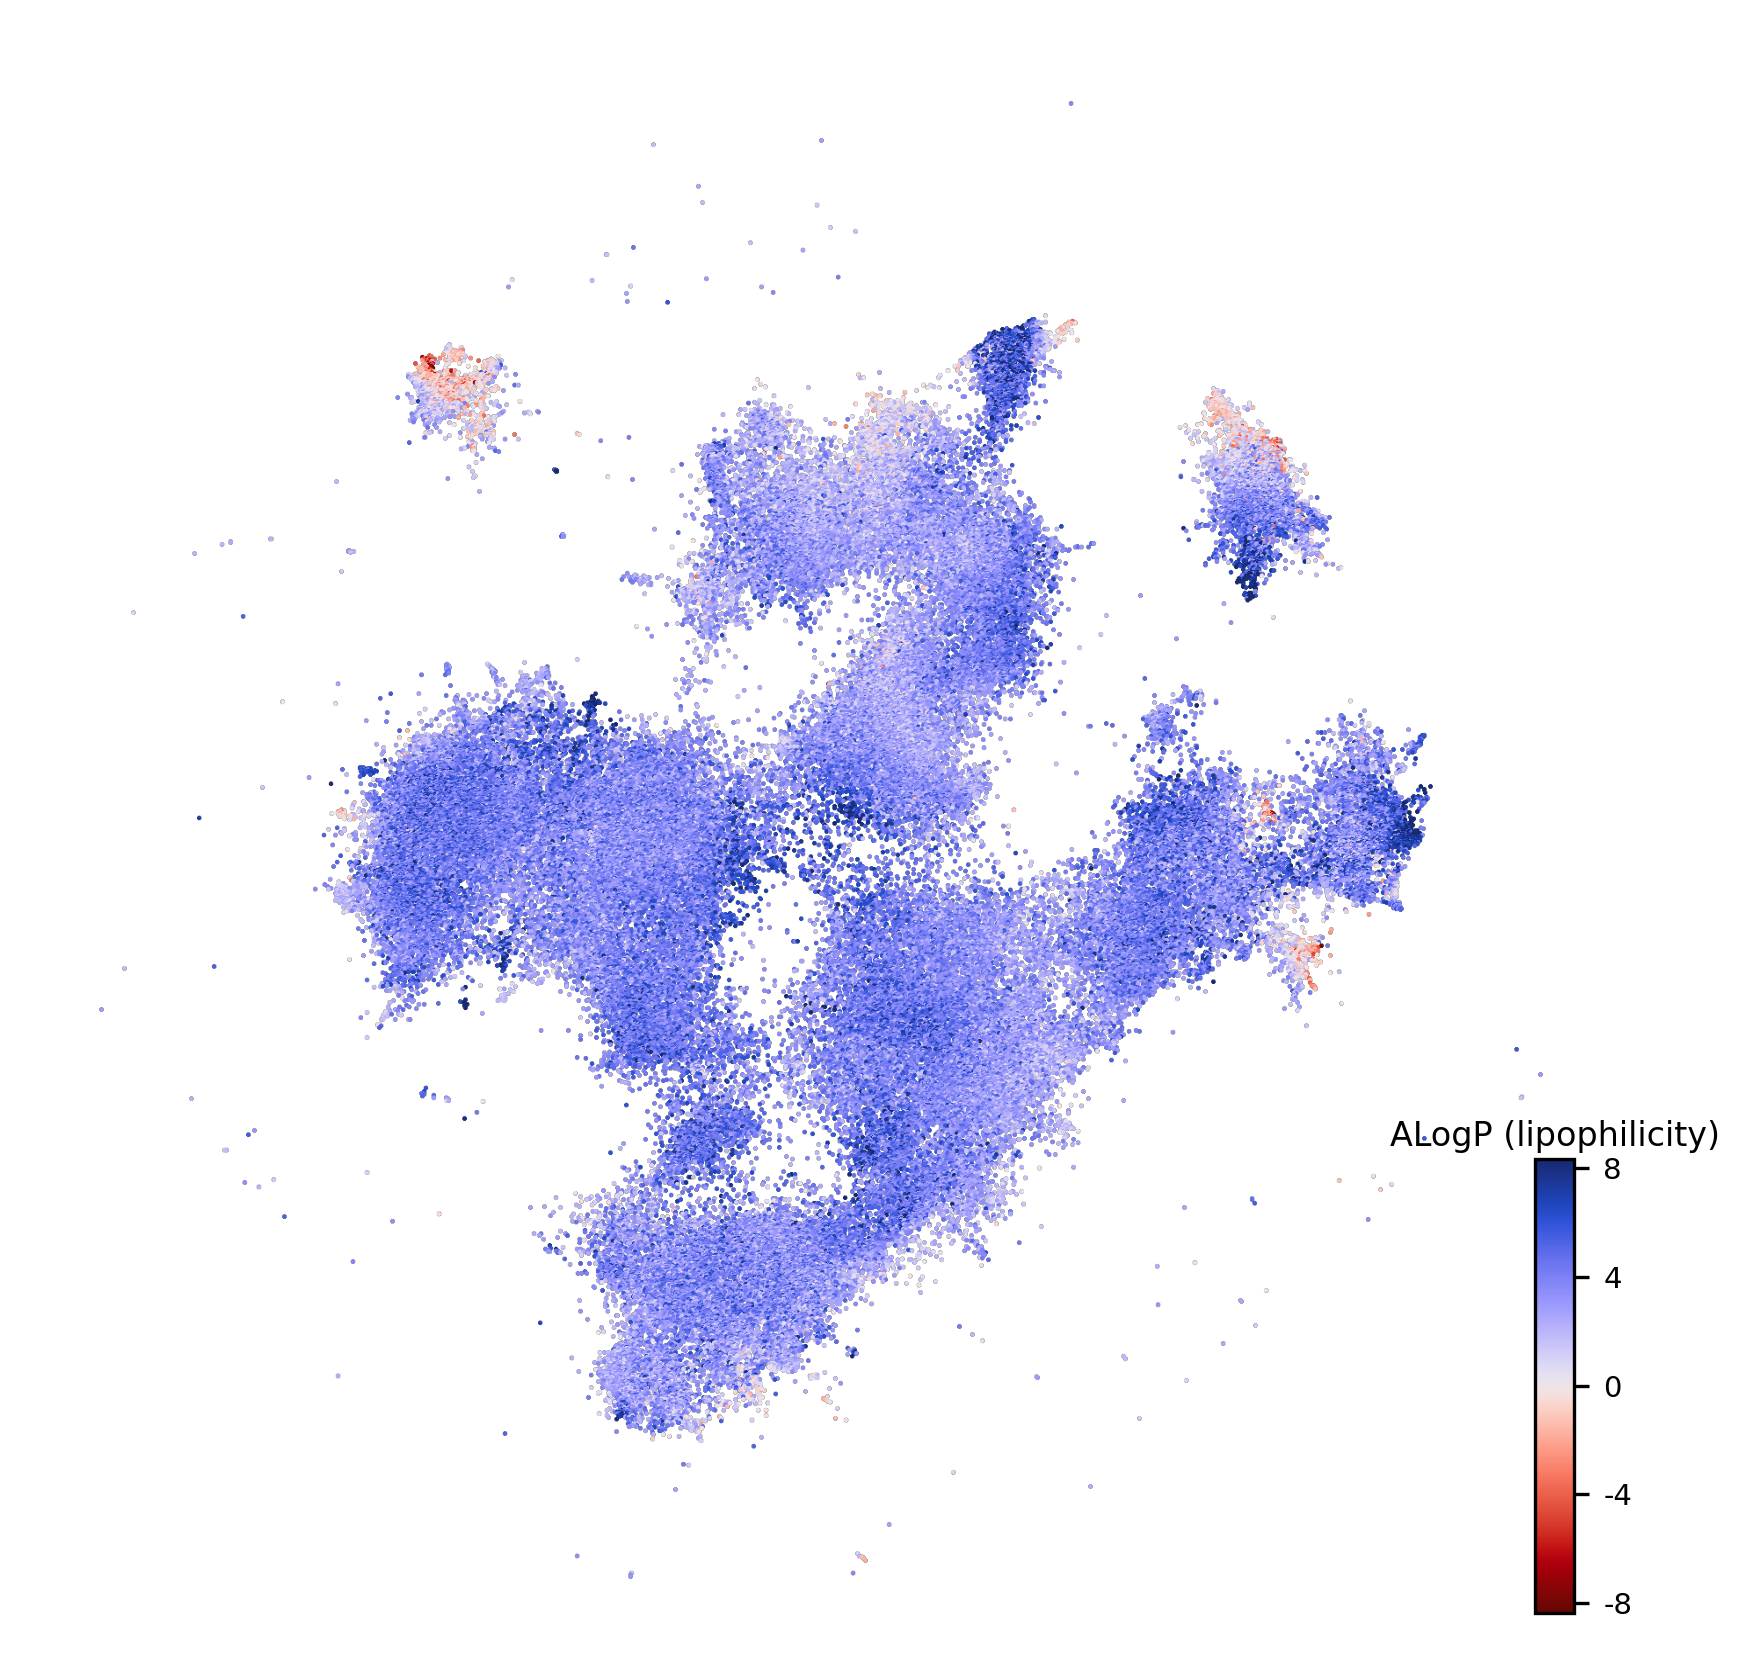

In [35]:
# Optional preview of the first selected measure.
preview_measure = MEASURES[0]
fig = plot_fixed_pacmap(coords, meta, preview_measure)
plt.show()

In [36]:
required_names = ["coords", "meta", "MEASURES", "RUN_ID", "plot_fixed_pacmap", "COLOR_LIMITS"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Run the setup cells above before exporting. Missing: " + ", ".join(missing_names)
    )


def save_measure_figure(measure: str) -> dict[str, object]:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    measure_fig = plot_fixed_pacmap(coords, meta, measure)
    base_name = f"{RUN_ID}_{slug(measure)}"
    exports = []
    requested_formats = {fmt.lower().lstrip(".") for fmt in EXPORT_FORMATS}

    # Save PNG first and derive PDF from the PNG. Direct Matplotlib PDF export
    # can duplicate the raster datashader layer and break inset colorbars.
    png_path = FIGURE_DIR / f"{base_name}.png"
    measure_fig.savefig(png_path, dpi=FIGURE_SPEC["dpi"], facecolor="white")
    exports.append(png_path)
    print(f"Wrote {png_path}")

    if "pdf" in requested_formats:
        pdf_path = FIGURE_DIR / f"{base_name}.pdf"
        with Image.open(png_path) as image:
            image.convert("RGB").save(pdf_path, "PDF", resolution=FIGURE_SPEC["dpi"])
        exports.append(pdf_path)
        print(f"Wrote {pdf_path} from PNG")

    for fmt in sorted(requested_formats - {"png", "pdf"}):
        output_path = FIGURE_DIR / f"{base_name}.{fmt}"
        measure_fig.savefig(output_path, dpi=FIGURE_SPEC["dpi"], facecolor="white")
        exports.append(output_path)
        print(f"Wrote {output_path}")
    plt.close(measure_fig)
    return {
        "run_id": RUN_ID,
        "measure": measure,
        "label": COLUMN_LABELS.get(measure, measure),
        "png_path": next((path for path in exports if path.suffix == ".png"), None),
        "exports": exports,
        "color_vmin": COLOR_LIMITS[measure]["vmin"],
        "color_vmax": COLOR_LIMITS[measure]["vmax"],
        "clip_low": COLOR_LIMITS[measure]["clip_low"],
        "clip_high": COLOR_LIMITS[measure]["clip_high"],
        "observed_min": COLOR_LIMITS[measure]["observed_min"],
        "observed_max": COLOR_LIMITS[measure]["observed_max"],
        "color_ticks": COLOR_LIMITS[measure]["ticks"],
        "color_scale_mode": COLOR_LIMITS[measure]["mode"],
        "n_winsorized_low": COLOR_LIMITS[measure]["n_winsorized_low"],
        "n_winsorized_high": COLOR_LIMITS[measure]["n_winsorized_high"],
        "pct_winsorized_low": COLOR_LIMITS[measure]["pct_winsorized_low"],
        "pct_winsorized_high": COLOR_LIMITS[measure]["pct_winsorized_high"],
        **PACMAP_PARAMS,
    }


records = [save_measure_figure(measure) for measure in MEASURES]
manifest = pd.DataFrame(
    [
        {
            **record,
            "png_path": str(record["png_path"]) if record["png_path"] is not None else None,
            "exports": [str(path) for path in record["exports"]],
        }
        for record in records
    ]
)
manifest_path = FIGURE_DIR / f"{RUN_ID}_measure_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print(f"Wrote {manifest_path}")


def pane_font(size: int, *, bold: bool = False) -> ImageFont.ImageFont:
    candidates = [
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "",
        "/System/Library/Fonts/Supplemental/Arial.ttf",
        "/Library/Fonts/Arial.ttf",
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return ImageFont.truetype(candidate, size=size)
    return ImageFont.load_default()


def arrange_measure_panel(
    records: list[dict[str, object]],
    *,
    out_path: Path,
    n_columns: int = PANEL_N_COLUMNS,
    tile_width: int = PANEL_TILE_WIDTH,
    padding: int = PANEL_PADDING,
) -> Path:
    panes = [record for record in records if record.get("png_path") is not None]
    if not panes:
        raise ValueError("No PNG panes available to arrange")

    with Image.open(panes[0]["png_path"]) as first:
        aspect = first.height / first.width
    tile_size = (tile_width, round(tile_width * aspect))
    n_columns = max(1, min(n_columns, len(panes)))
    n_rows = int(np.ceil(len(panes) / n_columns))

    title_font = pane_font(34, bold=True)
    label_font = pane_font(22, bold=True)
    small_font = pane_font(17)

    title_h = 82
    label_h = 36
    width = n_columns * tile_size[0] + (n_columns - 1) * padding
    height = title_h + n_rows * (label_h + tile_size[1]) + (n_rows - 1) * padding
    canvas = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(canvas)

    title = f"PaCMAP fixed-parameter measure panel: {RUN_ID}"
    subtitle = f"n_neighbors={PACMAP_PARAMS['n_neighbors']}, MN_ratio={PACMAP_PARAMS['MN_ratio']}, FP_ratio={PACMAP_PARAMS['FP_ratio']}"
    draw.text((0, 14), title, fill=(20, 20, 20), font=title_font)
    draw.text((2, 52), subtitle, fill=(70, 70, 70), font=small_font)

    for idx, pane in enumerate(panes):
        row = idx // n_columns
        col = idx % n_columns
        x = col * (tile_size[0] + padding)
        y = title_h + row * (label_h + tile_size[1] + padding)
        panel_letter = chr(ord("A") + idx)
        label = f"{panel_letter}. {pane['label']}"
        draw.text((x + 4, y + 4), label, fill=(35, 35, 35), font=label_font)

        with Image.open(pane["png_path"]) as image:
            image = ImageOps.contain(image.convert("RGB"), tile_size)
        tile = Image.new("RGB", tile_size, "white")
        offset = ((tile_size[0] - image.width) // 2, (tile_size[1] - image.height) // 2)
        tile.paste(image, offset)
        canvas.paste(tile, (x, y + label_h))
        draw.rectangle(
            [x, y + label_h, x + tile_size[0] - 1, y + label_h + tile_size[1] - 1],
            outline=(225, 225, 225),
        )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(out_path)
    print(f"Wrote {out_path} ({canvas.width}x{canvas.height})")
    return out_path


panel_path = None
if MAKE_MEASURE_PANEL and len(records) > 1:
    panel_path = arrange_measure_panel(records, out_path=FIGURE_DIR / f"{RUN_ID}_measure_panel.png")
elif MAKE_MEASURE_PANEL:
    print("Only one measure selected; skipping panel assembly")

config_path = FIGURE_DIR / f"{RUN_ID}_fixed_measure_config.json"
config_path.write_text(
    json.dumps(
        {
            "embedding_dir": str(EMBED_DIR),
            "source_parquet": str(SOURCE_PARQUET),
            "figure_dir": str(FIGURE_DIR),
            "coords_path": str(COORDS_PATH),
            "measures": MEASURES,
            "pacmap_params": PACMAP_PARAMS,
            "winsorize_percentile": WINSORIZE_PERCENTILE,
            "signed_color_scale": SIGNED_COLOR_SCALE,
            # "colorbar_tick_count": COLORBAR_TICK_COUNT,
            "color_limit_overrides": COLOR_LIMIT_OVERRIDES,
            "color_limits": COLOR_LIMITS,
            "figure_spec": FIGURE_SPEC,
            "manifest_path": str(manifest_path),
            "panel_path": str(panel_path) if panel_path is not None else None,
        },
        indent=2,
    ),
    encoding="utf-8",
)
print(f"Wrote {config_path}")

Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_alogp.png
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_alogp.pdf from PNG
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_psa.png
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_psa.pdf from PNG
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_hba.png
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_hba.pdf from PNG
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_hbd.png
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_hbd.pdf from PNG
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_qed_weighted.png
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_qed_weighted.pdf from PNG
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_mw_freebase.png
Wrote ../../figures/pacmap/manuscript_figures/nn040_mn0p25_fp12p0_mw_freebase.pdf from PNG
Wrote ../../figures/